# Ensemble of 4 Models — Chest X-Ray Pneumonia (Pure PyTorch)

| Component | Detail |
|-----------|--------|
| Dataset | Chest X-Ray Pneumonia (Kaggle — `paultimothymooney/chest-xray-pneumonia`) |
| Framework | **Pure PyTorch** (no Keras / TensorFlow) |
| Members | ResNet50 (torchvision) + VGG19-BN (torchvision) + Swin-Base (timm) + DeiT-Base (timm) |
| Preprocessing | CLAHE + Gaussian Blur + Resize/CenterCrop + ImageNet Normalize |
| Anti-overfitting | Random downsampling (class balance), Label Smoothing, AdamW + L2, Dropout, RandomErasing **after** ToTensor, Freeze→Fine-tune (progressive unfreeze), Cosine LR, Early Stopping |
| Ensemble | Soft Voting (avg softmax) + Weighted (val-acc) + Hard Voting |

> All four members share the **same** preprocessing, splits and anti-overfitting recipe — only the backbone changes. This guarantees a fair ensemble and avoids data leakage between members.

## 1. Imports & Reproducibility

In [1]:
import os, time, math, random, copy, gc, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision
import torchvision.transforms as T
from torchvision import models as tv_models

import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# AMP (PyTorch >= 2.x prefers torch.amp; fall back to torch.cuda.amp)
try:
    from torch.amp import autocast as _autocast, GradScaler as _GradScaler
    def make_scaler():
        return _GradScaler('cuda', enabled=torch.cuda.is_available())
    def amp_ctx():
        return _autocast('cuda', enabled=torch.cuda.is_available())
except ImportError:
    from torch.cuda.amp import autocast as _autocast, GradScaler as _GradScaler
    def make_scaler():
        return _GradScaler(enabled=torch.cuda.is_available())
    def amp_ctx():
        return _autocast(enabled=torch.cuda.is_available())

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print(f'timm   : {timm.__version__}')

Device : cuda
PyTorch: 2.10.0+cu128
timm   : 1.0.25


## 2. Configuration

Tune `epochs_freeze` / `epochs_finetune` if a Kaggle T4 session runs short.

In [7]:
CFG = dict(
    img_size            = 224,
    batch_size          = 16,
    num_workers         = 2,
    num_classes         = 2,
    class_names         = ['NORMAL', 'PNEUMONIA'],

    # Two-phase training: freeze backbone first, then fine-tune entire model
    epochs_freeze       = 2,
    epochs_finetune     = 5,
    lr_freeze           = 3e-4,
    lr_finetune         = 3e-5,
    weight_decay        = 1e-4,           # L2
    label_smoothing     = 0.10,
    dropout             = 0.40,
    grad_clip           = 1.0,
    early_stop_patience = 3,
    use_se_block        = True,           # SE on the head feature vector

    # Reserve a stratified validation split out of the train set
    val_frac            = 0.10,
    save_dir            = '/kaggle/working',
)
os.makedirs(CFG['save_dir'], exist_ok=True)
print(CFG)

{'img_size': 224, 'batch_size': 16, 'num_workers': 2, 'num_classes': 2, 'class_names': ['NORMAL', 'PNEUMONIA'], 'epochs_freeze': 2, 'epochs_finetune': 5, 'lr_freeze': 0.0003, 'lr_finetune': 3e-05, 'weight_decay': 0.0001, 'label_smoothing': 0.1, 'dropout': 0.4, 'grad_clip': 1.0, 'early_stop_patience': 3, 'use_se_block': True, 'val_frac': 0.1, 'save_dir': '/kaggle/working'}


## 3. Locate Dataset

Works whether you added the Kaggle dataset via **+ Add Data** *or* let the notebook fetch it via `kagglehub`.

In [8]:
def find_dataset():
    candidates = [
        '/kaggle/input/chest-xray-pneumonia/chest_xray',
        '/kaggle/input/chest-xray-pneumonia',
    ]
    for c in candidates:
        if os.path.exists(c):
            for root, dirs, _ in os.walk(c):
                if all(s in dirs for s in ['train', 'test', 'val']):
                    return root
    try:
        import kagglehub
        dl_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')
        for root, dirs, _ in os.walk(dl_path):
            if all(s in dirs for s in ['train', 'test', 'val']):
                return root
    except Exception as e:
        print('kagglehub failed:', e)
    raise FileNotFoundError('Could not locate the Chest X-Ray Pneumonia dataset')

BASE_DIR  = find_dataset()
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR   = os.path.join(BASE_DIR, 'val')
TEST_DIR  = os.path.join(BASE_DIR, 'test')
print('Base:', BASE_DIR)

Base: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray


## 4. EDA — class counts

In [9]:
rows = []
for split in ['train', 'val', 'test']:
    for cls in CFG['class_names']:
        d = os.path.join(BASE_DIR, split, cls)
        if not os.path.exists(d):
            continue
        for f in os.listdir(d):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                rows.append({'Split': split, 'Class': cls})
df = pd.DataFrame(rows)
print(pd.crosstab(df['Split'], df['Class'], margins=True, margins_name='Total'))

Class  NORMAL  PNEUMONIA  Total
Split                          
test      234        390    624
train    1341       3875   5216
val         8          8     16
Total    1583       4273   5856


## 5. Dataset class with CLAHE + Gaussian Blur

Identical preprocessing across all 4 backbones. CLAHE is computed in `__getitem__`.

In [10]:
class XRayDataset(Dataset):
    """CLAHE on L-channel + Gaussian Blur, then optional torchvision transform."""
    def __init__(self, root_dir, class_names, transform=None):
        self.transform    = transform
        self.class_names  = class_names
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        self.samples      = []
        for cls in class_names:
            d = os.path.join(root_dir, cls)
            if not os.path.exists(d):
                continue
            for f in os.listdir(d):
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(d, f), self.class_to_idx[cls]))
        self._clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __len__(self):
        return len(self.samples)

    def _apply_clahe(self, img_rgb):
        lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
        lab[:, :, 0] = self._clahe.apply(lab[:, :, 0])
        out = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        out = cv2.GaussianBlur(out, (3, 3), sigmaX=0.5)
        return Image.fromarray(out)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img_bgr = cv2.imread(path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        pil_img = self._apply_clahe(img_rgb)
        if self.transform:
            pil_img = self.transform(pil_img)
        return pil_img, label

    @property
    def targets(self):
        return [s[1] for s in self.samples]


print('XRayDataset ready.')

XRayDataset ready.


## 6. Transforms

`RandomErasing` is placed **after** `ToTensor` (PIL has no `.shape`). All 4 backbones expect 224×224 ImageNet-normalised tensors.

In [12]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG = CFG['img_size']

train_tf = T.Compose([
    T.Resize(256),
    T.RandomCrop(IMG, padding=16, padding_mode='reflect'),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.15, contrast=0.15),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
])

eval_tf = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMG),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print('Transforms ready.')

Transforms ready.


## 7. Class balancing + stratified train / val split

PNEUMONIA is the majority class — randomly **undersample** it to match NORMAL, then carve a stratified validation slice out of the balanced training set. The official `test/` folder stays untouched as the held-out test set.

In [13]:
def build_balanced_indices(targets, seed=SEED):
    rng = np.random.RandomState(seed)
    targets = np.asarray(targets)
    counts  = Counter(targets.tolist())
    print('Original train counts:', dict(counts))
    min_n = min(counts.values())
    chosen = []
    for cls in counts:
        cls_idx = np.where(targets == cls)[0]
        chosen.extend(rng.choice(cls_idx, size=min_n, replace=False).tolist())
    rng.shuffle(chosen)
    return chosen


full_train_aug  = XRayDataset(TRAIN_DIR, CFG['class_names'], transform=train_tf)
full_train_eval = XRayDataset(TRAIN_DIR, CFG['class_names'], transform=eval_tf)

balanced_idx     = build_balanced_indices(full_train_aug.targets)
balanced_targets = [full_train_aug.targets[i] for i in balanced_idx]
print('Balanced size :', len(balanced_idx))

t_idx, v_idx = train_test_split(
    np.arange(len(balanced_idx)),
    test_size=CFG['val_frac'],
    stratify=balanced_targets,
    random_state=SEED,
)
final_train_idx = [balanced_idx[i] for i in t_idx]
final_val_idx   = [balanced_idx[i] for i in v_idx]

train_ds = Subset(full_train_aug,  final_train_idx)
val_ds   = Subset(full_train_eval, final_val_idx)
test_ds  = XRayDataset(TEST_DIR, CFG['class_names'], transform=eval_tf)

print(f'train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}')

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)

Original train counts: {0: 1341, 1: 3875}
Balanced size : 2682
train=2413  val=269  test=624


## 8. SE block + shared head

A small SE-style gating module on the pooled feature vector (1-D) — same idea as the SE variants in your individual notebooks, kept consistent across all 4 backbones. The shared head also adds Dropout for regularization.

In [15]:
class SEBlock1D(nn.Module):
    """Squeeze-and-Excitation gating on a 1-D feature vector."""
    def __init__(self, in_features, reduction=8):
        super().__init__()
        hidden = max(in_features // reduction, 8)
        self.fc1 = nn.Linear(in_features, hidden)
        self.fc2 = nn.Linear(hidden, in_features)

    def forward(self, x):
        s = F.relu(self.fc1(x), inplace=True)
        s = torch.sigmoid(self.fc2(s))
        return x * s


def build_head(in_features, num_classes, dropout, use_se):
    layers = []
    if use_se:
        layers.append(SEBlock1D(in_features))
    layers += [
        nn.Linear(in_features, 512),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(512, num_classes),
    ]
    return nn.Sequential(*layers)

## 9. Model builders (4 PyTorch backbones)

Each wrapper exposes `.backbone` (frozen during phase 1) and `.head`. All output `num_classes=2` logits.

In [16]:
class ResNet50Wrapper(nn.Module):
    def __init__(self, num_classes, dropout, use_se):
        super().__init__()
        m = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V2)
        in_f = m.fc.in_features
        m.fc = nn.Identity()
        self.backbone = m
        self.head     = build_head(in_f, num_classes, dropout, use_se)

    def forward(self, x):
        return self.head(self.backbone(x))


class VGG19Wrapper(nn.Module):
    """VGG19-BN with a GAP-based head (lighter, less prone to overfit than the original 4096-dim FC)."""
    def __init__(self, num_classes, dropout, use_se):
        super().__init__()
        m = tv_models.vgg19_bn(weights=tv_models.VGG19_BN_Weights.IMAGENET1K_V1)
        self.backbone = m.features
        self.gap      = nn.AdaptiveAvgPool2d(1)
        self.head     = build_head(512, num_classes, dropout, use_se)

    def forward(self, x):
        x = self.backbone(x)
        x = self.gap(x).flatten(1)
        return self.head(x)


class TimmWrapper(nn.Module):
    """Generic timm wrapper — used for Swin and DeiT."""
    def __init__(self, model_name, num_classes, dropout, use_se):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=True, num_classes=0)
        in_f = self.backbone.num_features
        self.head = build_head(in_f, num_classes, dropout, use_se)

    def forward(self, x):
        return self.head(self.backbone(x))


def build_resnet50():
    return ResNet50Wrapper(CFG['num_classes'], CFG['dropout'], use_se=CFG['use_se_block'])

def build_vgg19():
    return VGG19Wrapper(CFG['num_classes'], CFG['dropout'], use_se=CFG['use_se_block'])

def build_swin():
    return TimmWrapper('swin_base_patch4_window7_224',
                       CFG['num_classes'], CFG['dropout'], use_se=CFG['use_se_block'])

def build_deit():
    return TimmWrapper('deit_base_patch16_224',
                       CFG['num_classes'], CFG['dropout'], use_se=CFG['use_se_block'])


MODEL_BUILDERS = {
    'resnet50': build_resnet50,
    'vgg19'   : build_vgg19,
    'swin'    : build_swin,
    'deit'    : build_deit,
}

# Quick sanity check — instantiate each on CPU to verify download / shape
for name, fn in MODEL_BUILDERS.items():
    m = fn()
    n_p = sum(p.numel() for p in m.parameters())
    print(f'{name:9s}  params = {n_p/1e6:7.2f} M')
    del m
gc.collect()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]


resnet50   params =   25.61 M
Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:02<00:00, 200MB/s] 


vgg19      params =   20.37 M


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

swin       params =   87.53 M


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

deit       params =   86.34 M


124

## 10. Training utilities

- **Phase 1** — backbone frozen, only the head trains (high LR, fast warm-up of the classifier).
- **Phase 2** — full fine-tune at a much smaller LR.
- Cosine LR per phase, AdamW + weight-decay (L2), label smoothing, AMP, gradient clipping, early stopping on validation accuracy.

In [17]:
def set_requires_grad(module, flag):
    for p in module.parameters():
        p.requires_grad = flag


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    logits_all, labels_all = [], []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        with amp_ctx():
            logits = model(x)
        logits_all.append(logits.float().cpu())
        labels_all.append(y)
    logits = torch.cat(logits_all)
    labels = torch.cat(labels_all)
    probs  = F.softmax(logits, dim=1).numpy()
    preds  = probs.argmax(1)
    acc    = accuracy_score(labels.numpy(), preds)
    return acc, probs, labels.numpy()


def train_phase(model, loader, optimizer, scheduler, criterion, scaler, n_epochs,
                phase_name, val_loader, best_state, best_val, patience,
                history, model_name):
    for ep in range(n_epochs):
        model.train()
        t0 = time.time()
        running = 0.0
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with amp_ctx():
                logits = model(x)
                loss   = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
            scaler.step(optimizer)
            scaler.update()
            running += loss.item() * x.size(0)
        scheduler.step()
        train_loss = running / len(loader.dataset)
        val_acc, _, _ = evaluate(model, val_loader)
        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)
        improved = val_acc > best_val
        marker   = '*' if improved else ' '
        print(f'[{model_name}] {phase_name} ep {ep+1:2d}/{n_epochs}  '
              f'loss={train_loss:.4f}  val_acc={val_acc:.4f}{marker}  '
              f'({time.time()-t0:.1f}s)')
        if improved:
            best_val   = val_acc
            best_state = copy.deepcopy(model.state_dict())
            patience   = 0
        else:
            patience += 1
            if patience >= CFG['early_stop_patience']:
                print(f'[{model_name}] Early stopping in {phase_name} (patience={patience}).')
                return best_state, best_val, patience, True
    return best_state, best_val, patience, False


def train_one_model(name, builder, save_path):
    model = builder().to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=CFG['label_smoothing'])
    scaler    = make_scaler()

    best_val   = 0.0
    best_state = copy.deepcopy(model.state_dict())
    patience   = 0
    history    = {'train_loss': [], 'val_acc': []}

    # ---- PHASE 1: freeze backbone ----
    set_requires_grad(model.backbone, False)
    set_requires_grad(model.head, True)
    p1_params = filter(lambda p: p.requires_grad, model.parameters())
    optim_p1  = optim.AdamW(p1_params, lr=CFG['lr_freeze'], weight_decay=CFG['weight_decay'])
    sched_p1  = optim.lr_scheduler.CosineAnnealingLR(
        optim_p1, T_max=max(1, CFG['epochs_freeze']))

    best_state, best_val, patience, stopped = train_phase(
        model, train_loader, optim_p1, sched_p1, criterion, scaler,
        CFG['epochs_freeze'], 'FREEZE', val_loader,
        best_state, best_val, patience, history, name,
    )

    # ---- PHASE 2: full fine-tune ----
    if not stopped:
        set_requires_grad(model.backbone, True)
        optim_p2 = optim.AdamW(model.parameters(),
                                lr=CFG['lr_finetune'], weight_decay=CFG['weight_decay'])
        sched_p2 = optim.lr_scheduler.CosineAnnealingLR(
            optim_p2, T_max=max(1, CFG['epochs_finetune']))
        best_state, best_val, patience, _ = train_phase(
            model, train_loader, optim_p2, sched_p2, criterion, scaler,
            CFG['epochs_finetune'], 'FT    ', val_loader,
            best_state, best_val, patience, history, name,
        )

    model.load_state_dict(best_state)
    torch.save(best_state, save_path)
    print(f'[{name}] BEST val_acc = {best_val:.4f}  ->  {save_path}')

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return best_val, history

## 11. Train all 4 members sequentially

Each model frees GPU memory before the next is built — works on a single Kaggle T4.

In [18]:
results = {}
for name, fn in MODEL_BUILDERS.items():
    print(f'\n{"="*72}\n  Training: {name.upper()}\n{"="*72}')
    save_path = os.path.join(CFG['save_dir'], f'{name}_best.pth')
    best_val, hist = train_one_model(name, fn, save_path)
    results[name] = {'val_acc': best_val, 'history': hist, 'path': save_path}

print('\nSummary (validation accuracy):')
for k, v in results.items():
    print(f'  {k:9s}  val_acc = {v["val_acc"]:.4f}')


  Training: RESNET50
[resnet50] FREEZE ep  1/2  loss=0.4427  val_acc=0.9294*  (109.4s)
[resnet50] FREEZE ep  2/2  loss=0.3679  val_acc=0.9368*  (106.4s)
[resnet50] FT     ep  1/5  loss=0.3500  val_acc=0.9517*  (107.7s)
[resnet50] FT     ep  2/5  loss=0.3111  val_acc=0.9591*  (107.4s)
[resnet50] FT     ep  3/5  loss=0.2978  val_acc=0.9665*  (107.6s)
[resnet50] FT     ep  4/5  loss=0.2951  val_acc=0.9554   (109.2s)
[resnet50] FT     ep  5/5  loss=0.2834  val_acc=0.9517   (114.3s)
[resnet50] BEST val_acc = 0.9665  ->  /kaggle/working/resnet50_best.pth

  Training: VGG19
[vgg19] FREEZE ep  1/2  loss=0.5706  val_acc=0.6283*  (112.4s)
[vgg19] FREEZE ep  2/2  loss=0.4252  val_acc=0.8439*  (109.4s)
[vgg19] FT     ep  1/5  loss=0.3399  val_acc=0.9628*  (111.3s)
[vgg19] FT     ep  2/5  loss=0.2985  val_acc=0.9554   (111.9s)
[vgg19] FT     ep  3/5  loss=0.2876  val_acc=0.9814*  (111.0s)
[vgg19] FT     ep  4/5  loss=0.2655  val_acc=0.9777   (110.1s)
[vgg19] FT     ep  5/5  loss=0.2609  val_acc=0.

[swin] FREEZE ep  1/2  loss=0.4874  val_acc=0.8773*  (104.0s)
[swin] FREEZE ep  2/2  loss=0.3813  val_acc=0.8996*  (103.3s)
[swin] FT     ep  1/5  loss=0.3815  val_acc=0.9554*  (108.4s)
[swin] FT     ep  2/5  loss=0.3128  val_acc=0.9591*  (108.8s)
[swin] FT     ep  3/5  loss=0.2617  val_acc=0.9591   (108.1s)
[swin] FT     ep  4/5  loss=0.2473  val_acc=0.9777*  (109.1s)
[swin] FT     ep  5/5  loss=0.2423  val_acc=0.9703   (108.5s)
[swin] BEST val_acc = 0.9777  ->  /kaggle/working/swin_best.pth

  Training: DEIT
[deit] FREEZE ep  1/2  loss=0.4157  val_acc=0.9145*  (103.3s)
[deit] FREEZE ep  2/2  loss=0.3399  val_acc=0.9108   (103.2s)
[deit] FT     ep  1/5  loss=0.3196  val_acc=0.9554*  (106.9s)
[deit] FT     ep  2/5  loss=0.2684  val_acc=0.9554   (106.1s)
[deit] FT     ep  3/5  loss=0.2561  val_acc=0.9591*  (105.3s)
[deit] FT     ep  4/5  loss=0.2428  val_acc=0.9628*  (105.6s)
[deit] FT     ep  5/5  loss=0.2390  val_acc=0.9703*  (106.3s)
[deit] BEST val_acc = 0.9703  ->  /kaggle/working/

## 12. Inference — collect softmax probabilities from each member

In [19]:
all_probs  = {}
all_labels = None
for name, fn in MODEL_BUILDERS.items():
    print(f'Inference: {name}')
    model = fn().to(DEVICE)
    state = torch.load(results[name]['path'], map_location=DEVICE)
    model.load_state_dict(state)
    acc, probs, labels = evaluate(model, test_loader)
    print(f'  test_acc = {acc:.4f}')
    all_probs[name] = probs
    all_labels      = labels
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

Inference: resnet50
  test_acc = 0.9135
Inference: vgg19
  test_acc = 0.8926
Inference: swin
  test_acc = 0.8734
Inference: deit
  test_acc = 0.8702


## 13. Ensembling strategies

1. **Soft Voting** — mean of softmax probabilities across all 4 members.
2. **Weighted Soft Voting** — weighted by each member's validation accuracy (best-performing model dominates).
3. **Hard Voting** — majority vote on argmax predictions; ties broken by soft-voting probability.

In [20]:
def metrics_block(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, average='binary', pos_label=1, zero_division=0)
    rec = recall_score(   y_true, y_pred, average='binary', pos_label=1, zero_division=0)
    f1  = f1_score(       y_true, y_pred, average='binary', pos_label=1, zero_division=0)
    print(f'  {name:24s}  acc={acc:.4f}  prec={pre:.4f}  rec={rec:.4f}  f1={f1:.4f}')
    return dict(acc=acc, prec=pre, rec=rec, f1=f1)


names      = list(all_probs.keys())
prob_stack = np.stack([all_probs[n] for n in names], axis=0)   # (M, N, C)

# 1) Soft voting -----------------------------------------------------------
soft_probs = prob_stack.mean(axis=0)
soft_pred  = soft_probs.argmax(1)

# 2) Weighted soft voting (val-acc weights) --------------------------------
w = np.array([results[n]['val_acc'] for n in names], dtype=np.float64)
w = w / (w.sum() + 1e-12)
weighted_probs = (prob_stack * w[:, None, None]).sum(axis=0)
weighted_pred  = weighted_probs.argmax(1)
print('Weights:', dict(zip(names, np.round(w, 3))))

# 3) Hard (majority) voting with soft-vote tiebreak ------------------------
hard_votes = prob_stack.argmax(axis=2)                          # (M, N)
hard_pred  = []
for i in range(hard_votes.shape[1]):
    counts = Counter(hard_votes[:, i].tolist())
    top, n_top = counts.most_common(1)[0]
    if list(counts.values()).count(n_top) > 1:
        hard_pred.append(int(soft_probs[i].argmax()))
    else:
        hard_pred.append(top)
hard_pred = np.array(hard_pred)

print('\nPer-model TEST results:')
per_model_metrics = {n: metrics_block(n, all_labels, all_probs[n].argmax(1)) for n in names}

print('\nEnsemble TEST results:')
m_soft = metrics_block('Soft Voting (avg)',       all_labels, soft_pred)
m_wt   = metrics_block('Weighted (val-acc)',      all_labels, weighted_pred)
m_hard = metrics_block('Hard Voting (majority)',  all_labels, hard_pred)

Weights: {'resnet50': np.float64(0.248), 'vgg19': np.float64(0.252), 'swin': np.float64(0.251), 'deit': np.float64(0.249)}

Per-model TEST results:
  resnet50                  acc=0.9135  prec=0.9038  rec=0.9641  f1=0.9330
  vgg19                     acc=0.8926  prec=0.8613  rec=0.9872  f1=0.9200
  swin                      acc=0.8734  prec=0.8330  rec=0.9974  f1=0.9078
  deit                      acc=0.8702  prec=0.8294  rec=0.9974  f1=0.9057

Ensemble TEST results:
  Soft Voting (avg)         acc=0.8958  prec=0.8587  rec=0.9974  f1=0.9229
  Weighted (val-acc)        acc=0.8958  prec=0.8587  rec=0.9974  f1=0.9229
  Hard Voting (majority)    acc=0.8926  prec=0.8549  rec=0.9974  f1=0.9207


## 14. Confusion matrices & classification report

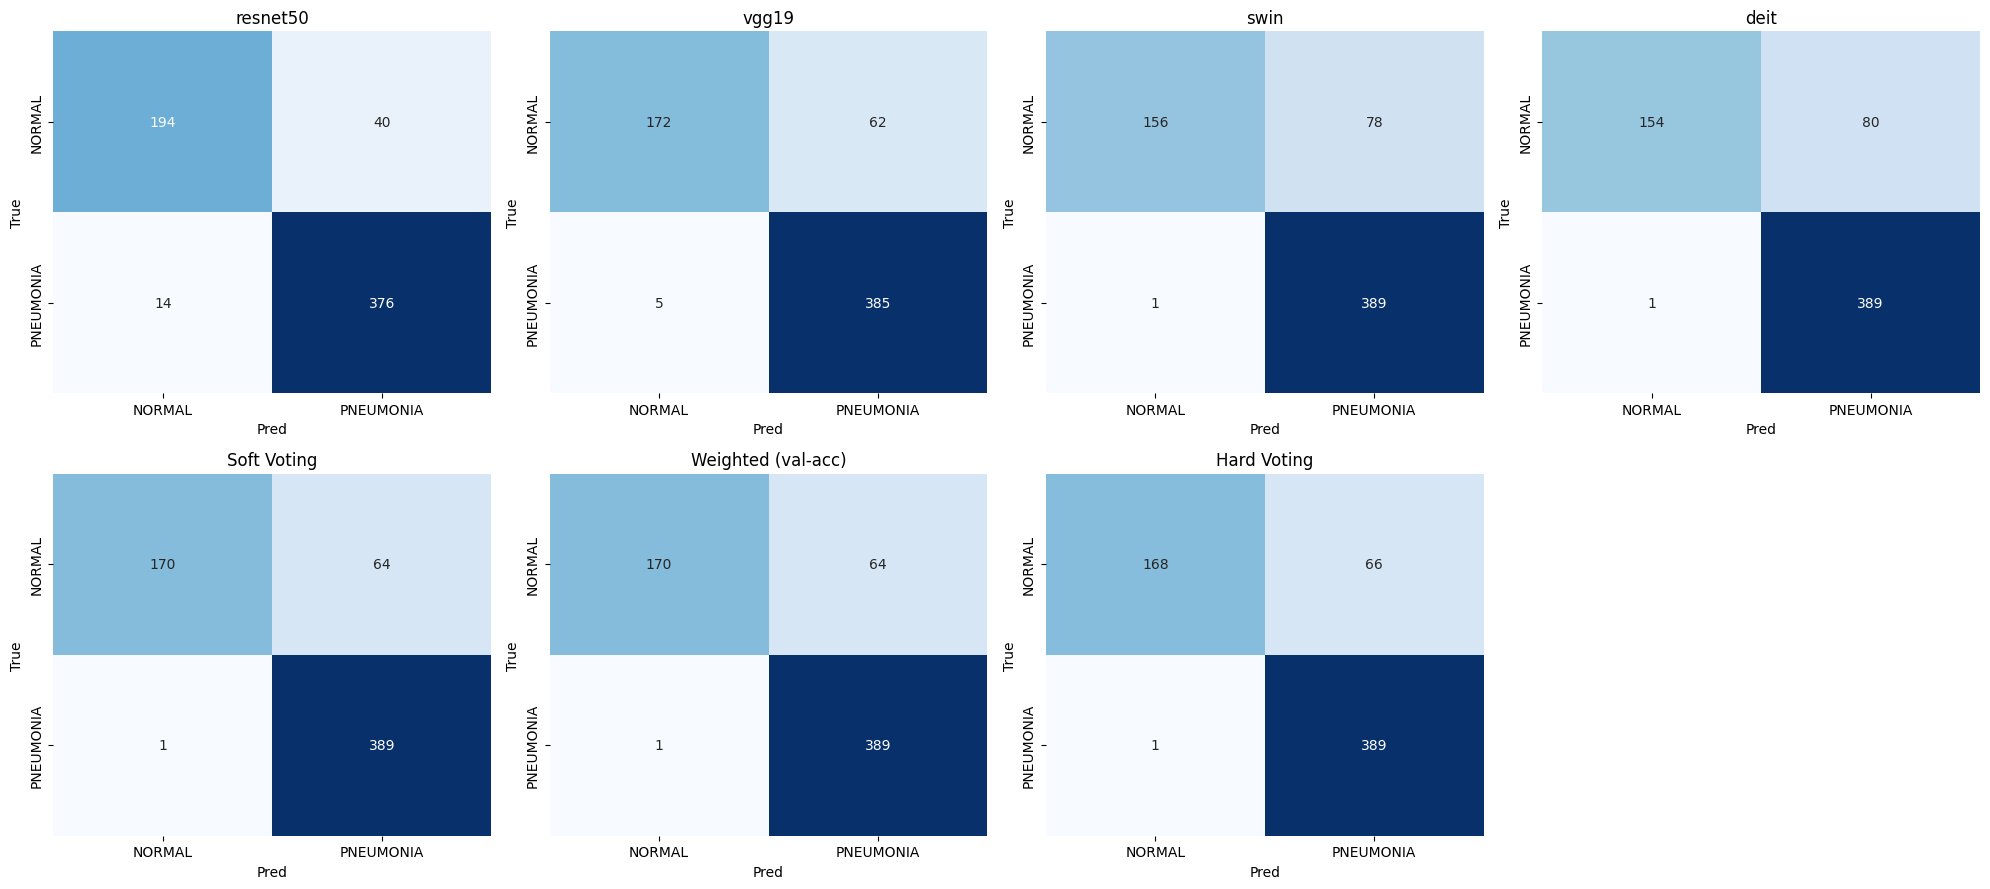

Classification report — Weighted Soft-Voting Ensemble
              precision    recall  f1-score   support

      NORMAL     0.9942    0.7265    0.8395       234
   PNEUMONIA     0.8587    0.9974    0.9229       390

    accuracy                         0.8958       624
   macro avg     0.9264    0.8620    0.8812       624
weighted avg     0.9095    0.8958    0.8916       624



In [21]:
def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=CFG['class_names'], yticklabels=CFG['class_names'], ax=ax)
    ax.set_title(title); ax.set_xlabel('Pred'); ax.set_ylabel('True')

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
ax = axes.flatten()
for i, n in enumerate(names):
    plot_cm(ax[i], all_labels, all_probs[n].argmax(1), n)
plot_cm(ax[4], all_labels, soft_pred,     'Soft Voting')
plot_cm(ax[5], all_labels, weighted_pred, 'Weighted (val-acc)')
plot_cm(ax[6], all_labels, hard_pred,     'Hard Voting')
ax[7].axis('off')
plt.tight_layout(); plt.show()

print('Classification report — Weighted Soft-Voting Ensemble')
print(classification_report(all_labels, weighted_pred,
                            target_names=CFG['class_names'], digits=4))

## 15. Final summary table

In [22]:
summary_rows = []
for n in names:
    row = {'model': n, 'val_acc': results[n]['val_acc']}
    row.update(per_model_metrics[n])
    summary_rows.append(row)
for tag, m in [('Soft Voting', m_soft), ('Weighted (val-acc)', m_wt), ('Hard Voting', m_hard)]:
    summary_rows.append({'model': tag, 'val_acc': float('nan'), **m})

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
summary_df.to_csv(os.path.join(CFG['save_dir'], 'ensemble_summary.csv'), index=False)
print('\nSaved:', os.path.join(CFG['save_dir'], 'ensemble_summary.csv'))

             model  val_acc      acc     prec      rec       f1
          resnet50 0.966543 0.913462 0.903846 0.964103 0.933002
             vgg19 0.981413 0.892628 0.861298 0.987179 0.919952
              swin 0.977695 0.873397 0.832976 0.997436 0.907818
              deit 0.970260 0.870192 0.829424 0.997436 0.905704
       Soft Voting      NaN 0.895833 0.858720 0.997436 0.922894
Weighted (val-acc)      NaN 0.895833 0.858720 0.997436 0.922894
       Hard Voting      NaN 0.892628 0.854945 0.997436 0.920710

Saved: /kaggle/working/ensemble_summary.csv
